In [1]:
!pip install diffusers transformers accelerate torch pillow --quiet

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


⚠️ WARNING: Running on CPU. This will be very slow. Switch your Colab runtime to T4 GPU!
Loading model weights from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Generating image for: 'A majestic glowing crystal dragon perched on top of a snow-covered mountain peak, digital art, highly detailed'...


  0%|          | 0/25 [00:00<?, ?it/s]


Generation Complete! Your image:


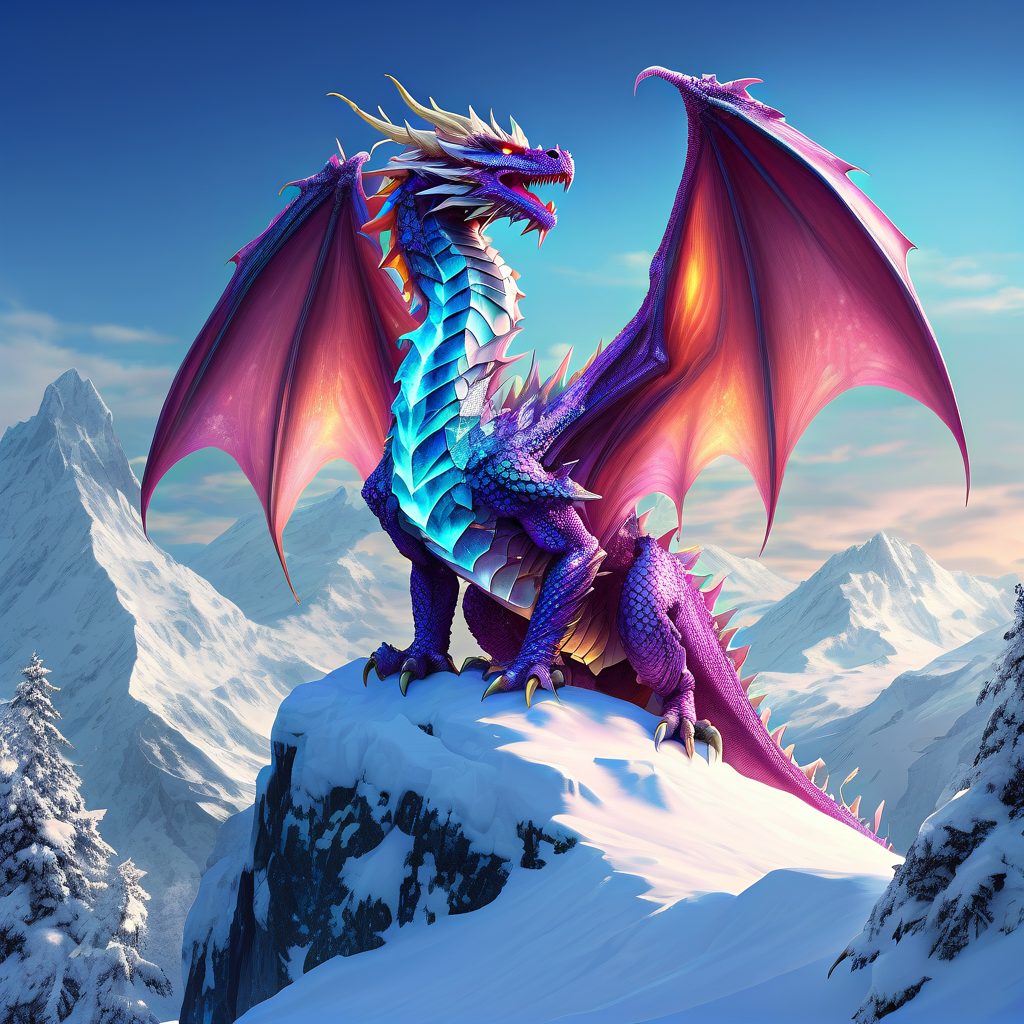

In [2]:
import torch
from diffusers import StableDiffusionXLPipeline
from IPython.display import display

def generate_and_display_image(prompt: str, filename: str = "output.png"):
    # 1. Automatically check if Colab GPU is enabled
    if torch.cuda.is_available():
        device = "cuda"
        dtype = torch.float16
        print("Using GPU Acceleration (T4).")
    else:
        device = "cpu"
        dtype = torch.float32
        print("⚠️ WARNING: Running on CPU. This will be very slow. Switch your Colab runtime to T4 GPU!")

    # 2. Load an optimized, fast open-source model ideal for Colab
    model_id = "segmind/SSD-1B"

    print("Loading model weights from Hugging Face...")
    pipe = StableDiffusionXLPipeline.from_pretrained(
        model_id,
        torch_dtype=dtype,
        use_safetensors=True,
        variant="fp16" if device == "cuda" else None
    )
    pipe = pipe.to(device)

    # 3. Generate the image
    print(f"Generating image for: '{prompt}'...")
    # Using 25-30 steps is the sweet spot for speed and quality on this model
    result = pipe(prompt=prompt, num_inference_steps=25, guidance_scale=7.0)

    # 4. Save and instantly display in the notebook
    image = result.images[0]
    image.save(filename)

    print("\nGeneration Complete! Your image:")
    display(image)

# --- Execute Generation ---
# Feel free to change this text prompt to whatever you want to practice with!
user_prompt = "A majestic glowing crystal dragon perched on top of a snow-covered mountain peak, digital art, highly detailed"
generate_and_display_image(prompt=user_prompt)